In [1]:
from os import listdir as ls
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import arviz as az

from emu_renewal.inputs import get_world_shp
from emu_renewal.constants import OUTPUTS_PATH, OXCGRT_LOCATION_CMAP

<Axes: >

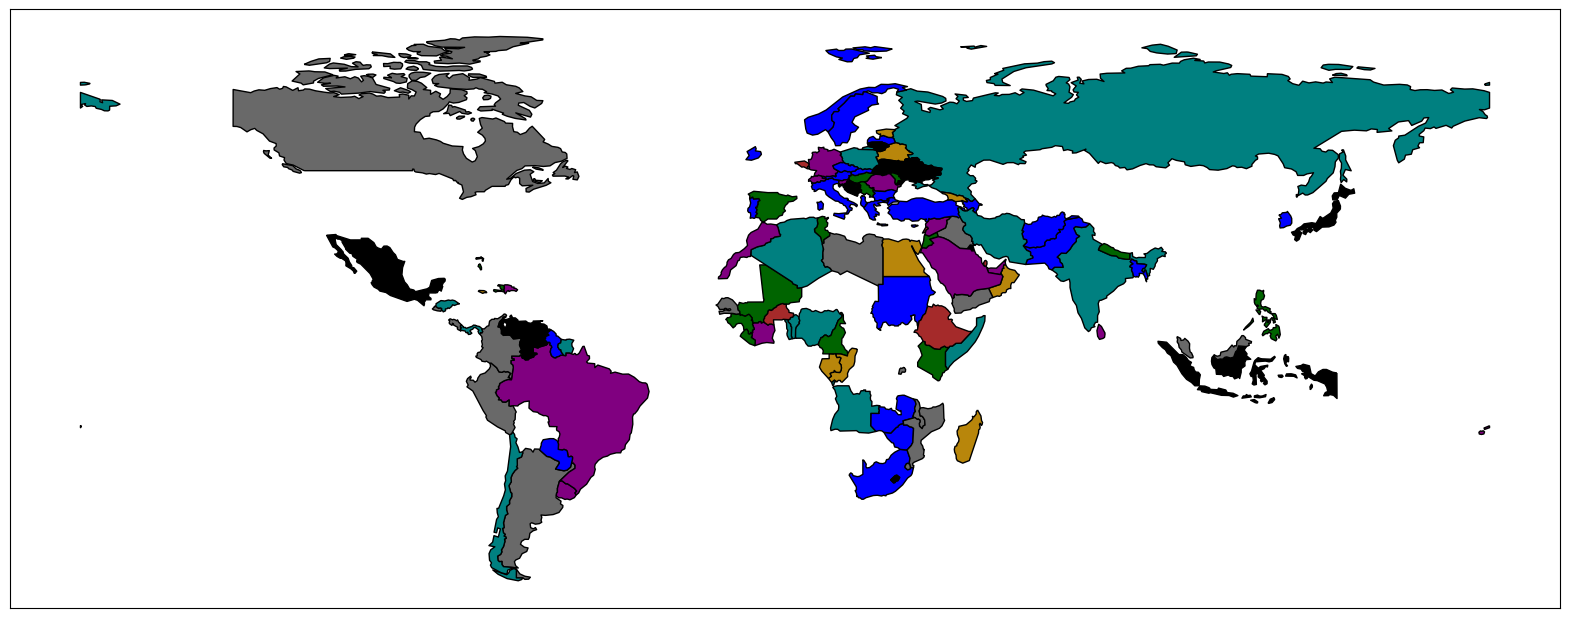

In [5]:
world = get_world_shp()
world["geometry"] = world.simplify(tolerance=0.1, preserve_topology=True)

job_path = OUTPUTS_PATH / "48930936"
all_countries = [iso3 for iso3 in ls(job_path) if "oxcgrt" in ls(job_path / iso3)]
top_policy = {}
for iso3 in all_countries:
    analysis_path = job_path / iso3 / "oxcgrt"
    idata = az.from_netcdf(analysis_path / "idata_filtered.nc")
    medians = idata.posterior["mob_weights"].median(dim=("chain", "draw"))
    best_policy = int(medians.argmax().item())
    top_policy[iso3] = best_policy
world["top_policy"] = world["SOV_A3"].map(top_policy).astype("Int64")

fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax.set_xticks([])
ax.set_yticks([])
cmap = mcolors.ListedColormap(OXCGRT_LOCATION_CMAP.values(), name="policy_map")
norm = mcolors.BoundaryNorm(boundaries=list(range(len(OXCGRT_LOCATION_CMAP))), ncolors=cmap.N)
world.plot(ax=ax, categorical=True, column="top_policy", vmin=-0.5, vmax=len(OXCGRT_LOCATION_CMAP) - 0.5, edgecolor="black", cmap=cmap)